In [98]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import re

First we will load all percipitation data before loading all the discharge data. This will then be saved into dataframes for further analysis.

In [99]:
percipitation_black = pd.read_csv(r"precipitation data volta\mswep\Black Volta_-2.75_9.55.csv", index_col=0, parse_dates=True)
percipitation_lake = pd.read_csv(r"precipitation data volta\mswep\Lake Volta_0.05_6.45.csv", index_col=0, parse_dates=True)
percipitation_mouhoun = pd.read_csv(r"precipitation data volta\mswep\Mouhoun_-3.95_12.05.csv", index_col=0, parse_dates=True)
percipitation_nakambe = pd.read_csv(r"precipitation data volta\mswep\Nakambe_-2.15_13.55.csv", index_col=0, parse_dates=True)
percipitation_oti = pd.read_csv(r"precipitation data volta\mswep\Oti_0.15_8.45.csv", index_col=0, parse_dates=True)
percipitation_pendjari = pd.read_csv(r"precipitation data volta\mswep\Pendjari_1.15_11.15.csv", index_col=0, parse_dates=True)


Discharge Data:

This data is loaded first to see what is going on. It is then split into the 2 rivers which it measures, and plotted against time. Data is taken 3 times per month. 

In [100]:
discharge = pd.read_excel(r"discharge data volta\discharge in columns.xlsx")
discharge.head()

,MOU HO,UN (VO,LTA NO,IRE),Unnamed: 4,Unnamed: 5,SA,MANDEN,I,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,1 11977
1,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,2 11977
2,2,2,2,2,2.0,2.0,2,2,2.0,2.0,2.0,3 11977
3,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,1 21977
4,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,2 21977


In [101]:

path = r"discharge data volta\discharge in columns.xlsx"
raw = pd.read_excel(path, header=None)

def is_number(x):
    try:
        float(x)
        return True
    except Exception:
        return False

def join_tokens(row, cols):
    toks = [row[c] for c in cols if pd.notna(row[c])]
    s = " ".join(map(str, toks))
    s = re.sub(r"\s+", " ", s).strip()
    return s

records = []
cur_river = None
cur_station = None

for _, row in raw.iterrows():
    # Header rows: first cell is not numeric -> contains river/station fragments
    if not is_number(row[0]):
        cur_river = join_tokens(row, range(0, 6))   # cols 0-5
        cur_station = join_tokens(row, range(6, 11)) # cols 6-10
        continue

    meta = row[11]
    if pd.isna(meta) or cur_river is None:
        continue

    # meta like "2 21977" -> r=2, month=2, year=1977
    parts = str(meta).split()
    if len(parts) != 2:
        continue
    r = int(parts[0])
    my = int(parts[1])
    month = my // 10000
    year = my % 10000

    # values live in cols 0..10 (10 values for row 1/2, up to 11 for row 3)
    vals = pd.to_numeric(row.loc[0:10], errors="coerce").dropna().to_list()
    start_day = (r - 1) * 10 + 1

    for i, v in enumerate(vals):
        day = start_day + i
        # build date; invalid dates (e.g., Feb 30) become NaT and are skipped
        dt = pd.to_datetime({"year": [year], "month": [month], "day": [day]}, errors="coerce")[0]
        if pd.isna(dt):
            continue

        if v == 9999:
            v = np.nan

        records.append({
            "Date": dt,
            "River": cur_river,
            "Station": cur_station,
            "Row": r,
            "Discharge": v
        })

df = pd.DataFrame(records).set_index("Date").sort_index()

# One dataframe per river (each retains Station/Row/Discharge as columns)
river_dfs = {riv: g.copy() for riv, g in df.groupby("River")}



In [102]:
river_names = list(river_dfs.keys())[:]
print(river_names)
df_river1, df_river2, df_river3 = (river_dfs[river_names[0]], river_dfs[river_names[1]], river_dfs[river_names[2]])

['BOUGOU RIBA', 'MOU HO UN (VO LTA NO IRE)', 'NAKANB E (VOL TA BLA NCHE)', 'NAZINO N (VOL TA ROU GE)', 'PENDJA RI', 'SINGOU', 'VOLTA NOIRE']


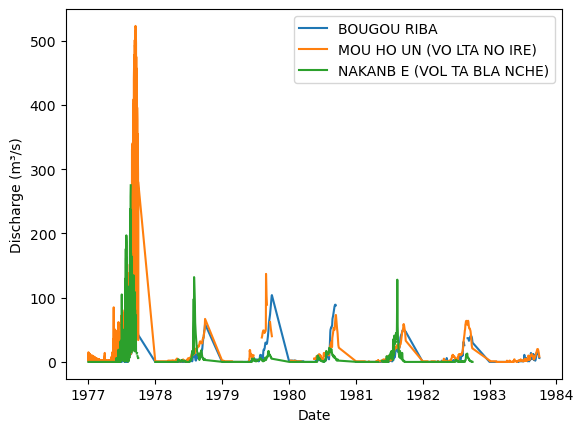

In [103]:
plt.plot(df_river1.index, df_river1["Discharge"], label=river_names[0])
plt.plot(df_river2.index, df_river2["Discharge"], label=river_names[1])
plt.plot(df_river3.index, df_river3["Discharge"], label=river_names[2])
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.show()

To analyse the water balance we also have to add the evaporation. To take into account evaporation we have to the daylight/sun hours per day. This data has to be found somewhere. 

In [104]:
## FROM IJSSELMEER CASE - THIS IS TO CALCULATE EVAPOTRANSPIRATION

def es_cal(T):
    es = 0.61 * np.exp((19.9 * T) / (273 + T))
    return es #kPa

def ea_cal(RH, T):
    ea = (RH / 100) * es_cal(T)
    return ea #kPa

def S_cal(T):
    S = (5430 * es_cal(T)) / (273 + T)**2
    return S #kPa/°C

def ra_cal(u):
    ra = (245 / (0.5 * u + 0.5)) 
    return ra #s/m

def EO(Rn, RH, T, u):
    rho = 1000 # density of water kg/m3
    rho_a = 1.205 # density of air kg/m3
    cp = 1004 # specific heat capacity of air J/(kg·K)
    gamma = 0.066 # psychrometric constant kPa/°C
    lam = 2.45e6 # latent heat of vaporization J/kg
    T = T
    es = es_cal(T)
    ea = ea_cal(RH, T)
    S = S_cal(T)
    ra = ra_cal(u)

    EO = (((S * Rn) / (rho * lam)) + ((cp * rho_a) / (rho * lam)) * ((es - ea) / ra)) / (S + gamma)
    return EO


Load the percipitation data and compare with the discharge data

In [105]:
filename = 'precipitation data volta\\mswep\\Black Volta_-2.75_9.55.csv'
blackvolta = pd.read_csv(filename, index_col=['time'], parse_dates=['time']) 
#Look what is in the file:
blackvolta.head(-15)

,precipitation
time,
1979-01-01,0.00
1979-01-02,0.00
1979-01-03,0.00
1979-01-04,0.00
1979-01-05,0.00
...,...
2017-10-12,12.33
2017-10-13,0.00
2017-10-14,0.06


Evaporation Data 

In [106]:
df_evap1 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed1.csv", index_col=0, parse_dates=True)

df_evap2 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed2.csv", index_col=0, parse_dates=True)

df_evap3 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed3.csv", index_col=0, parse_dates=True)

df_evap4 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed4.csv", index_col=0, parse_dates=True)

df_evap5 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed5.csv", index_col=0, parse_dates=True)

df_evap6 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed6.csv", index_col=0, parse_dates=True)

df_evap7 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed7.csv", index_col=0, parse_dates=True)

df_evap8 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed8.csv", index_col=0, parse_dates=True)


In [107]:
df_evap1.head()

,step,latitude,longitude,number,surface,valid_time,e
time,,,,,,,
1979-01-01,0 days 08:00:00,11.0,-3.0,0,0.0,1979-01-01 08:00:00,-0.000041
1979-01-01,0 days 08:00:00,11.0,-2.9,0,0.0,1979-01-01 08:00:00,-0.000037
1979-01-01,0 days 08:00:00,11.0,-2.8,0,0.0,1979-01-01 08:00:00,-0.000029
1979-01-01,0 days 08:00:00,11.0,-2.7,0,0.0,1979-01-01 08:00:00,-0.000030
1979-01-01,0 days 08:00:00,11.0,-2.6,0,0.0,1979-01-01 08:00:00,-0.000032


In [108]:
df_all = pd.concat(
    [df_evap1, df_evap2, df_evap3, df_evap4,
     df_evap5, df_evap6, df_evap7, df_evap8],
    ignore_index=True
)

df_all["valid_time"] = pd.to_datetime(df_all["valid_time"])

df_all["evap_mm"] = -df_all["e"] * 1000

df_evap_time = (
    df_all.groupby("valid_time")["evap_mm"]
          .mean()
          .to_frame()
          .sort_index()
)

# print(df_evap_time.head(50))
# print("\nSummary:")
# print(df_evap_time.describe())

In [109]:
df_evap_daily = df_evap_time.resample("1D").sum() * 2


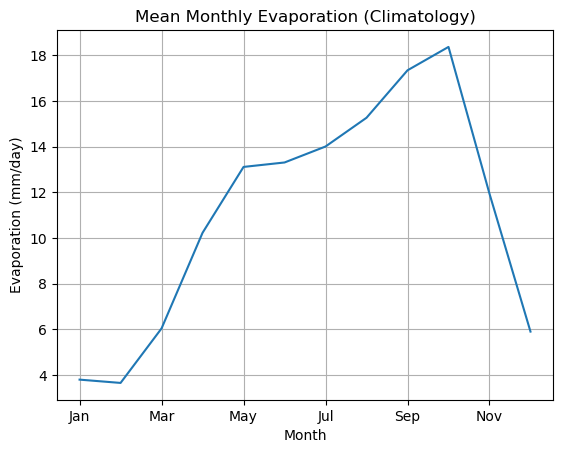


Monthly climatology (mm/day):
Jan     3.800805
Feb     3.656885
Mar     6.042264
Apr    10.225799
May    13.108949
Jun    13.303193
Jul    14.001970
Aug    15.260354
Sep    17.336522
Oct    18.359945
Nov    11.936413
Dec     5.902671
Name: evap_mm, dtype: float64

Seasonal means (mm/day):
season
DJF     4.477668
MAM     9.787626
JJA    14.198129
SON    15.904905
Name: evap_mm, dtype: float64


In [110]:

df_evap_daily.index = pd.to_datetime(df_evap_daily.index)

# ===============================
# 1. Monthly climatology (average seasonal cycle)
# ===============================
monthly_evap = (
    df_evap_daily
    .groupby(df_evap_daily.index.month)["evap_mm"]
    .mean()
)

# Replace month numbers with names
monthly_evap.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# ===============================
# 2. Add month + season columns
# ===============================
df_evap_daily["month"] = df_evap_daily.index.month

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

df_evap_daily["season"] = df_evap_daily["month"].apply(get_season)

# ===============================
# 3. Seasonal averages
# ===============================
seasonal_means = (
    df_evap_daily
    .groupby("season")["evap_mm"]
    .mean()
    .reindex(["DJF","MAM","JJA","SON"])
)


plt.figure()
monthly_evap.plot()
plt.title("Mean Monthly Evaporation (Climatology)")
plt.ylabel("Evaporation (mm/day)")
plt.xlabel("Month")
plt.grid(True)
plt.show()

print("\nMonthly climatology (mm/day):")
print(monthly_evap)

print("\nSeasonal means (mm/day):")
print(seasonal_means)

Design of the reservoirs

In [111]:
#parameters to be defined:

area = 1 * 10000 #m2 1 ha surface area of reservoir
Cr = 0.5 #runoff coefficient
Percip = 10 #mm/day changes per month
k = 0.01 #seepage coefficient m/day
E = 5 #mm/day evaporation changes per month
Rriver = 100 #mm/day river inflow
Dirr = 200 #direct abstraction (m3/day)
Airr = 20*1000 #area of irrigation (m2)
Acatch = 40*1000 #catchment area (m2)

In [112]:
def volume(area):
    volume = 0.00857 * area**1.4367
    return volume

def Rcatch(Cr, Percip, Acatch):
    Rcatch = Cr * Percip * Acatch
    return Rcatch

def Pdir(Percip, area):
    Pdir = Percip * area
    return Pdir

def evap(E, area):
    evap = E * area
    return evap

def seep(k, area, L=3):
    seep = k * area * (volume(area) / area) / L
    return seep

def abstract(Dirr, Airr):
    abstract = Dirr * Airr
    return abstract

def delta_s(Rriver=Rriver, E=E, area=area, percip=Percip, Cr=Cr, Acatch=Acatch, k=k, Dirr=Dirr, Airr=Airr, L=3):
    delta_s = (Rcatch(Cr, percip, Acatch) + Rriver + Pdir(percip, area)) - evap(E, area) - seep(area, k) - abstract(Dirr, Airr)
    return delta_s

For now a trial:


only the blackvolta percipitation data and black volta river discharge averaged to create a single design year. The aim will be to create the smallest reservoir that fullfills the irrigation needs for a specific area

Monthly design year precipitation (mm/day):
     precipitation
Jan       0.083251
Feb       0.317719
Mar       0.949768
Apr       2.488590
May       3.667395
Jun       3.886889
Jul       4.684202
Aug       5.669132
Sep       5.606342
Oct       2.530265
Nov       0.329482
Dec       0.066188


C:\Users\ellis\AppData\Local\Temp\ipykernel_33052\1298024135.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  precip_monthly = blackvolta.resample("M").mean()


<Figure size 640x480 with 0 Axes>

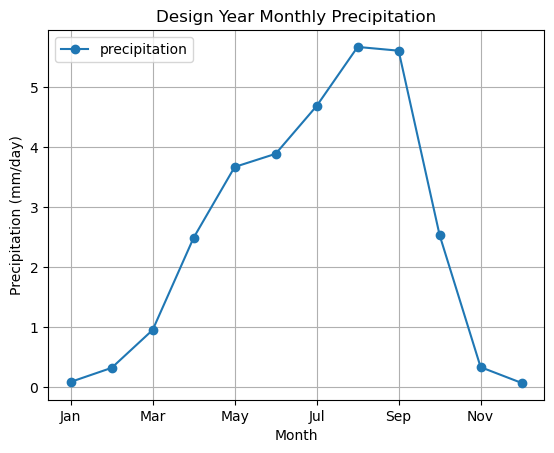

In [113]:
blackvolta.index = pd.to_datetime(blackvolta.index)

# If daily data → first aggregate to monthly totals (mm/month)
precip_monthly = blackvolta.resample("M").mean()

# Now compute climatological monthly average (design year)
precip_design_year = (
    precip_monthly
    .groupby(precip_monthly.index.month)
    .mean()
)

# Replace month numbers with names
precip_design_year.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

print("Monthly design year precipitation (mm/day):")
print(precip_design_year)

# Plot
plt.figure()
precip_design_year.plot(marker='o')
plt.title("Design Year Monthly Precipitation")
plt.ylabel("Precipitation (mm/day)")
plt.xlabel("Month")
plt.grid(True)
plt.show()

C:\Users\ellis\AppData\Local\Temp\ipykernel_33052\703791467.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  river_monthly = river_series.resample("M").mean()


Jan     1.835418
Feb     1.129750
Mar     0.655914
Apr     0.872222
May     3.555743
Jun     7.114024
Jul    12.429724
Aug    37.325594
Sep    69.278912
Oct     0.000000
Nov     0.000000
Dec     0.000000
Name: Discharge, dtype: float64


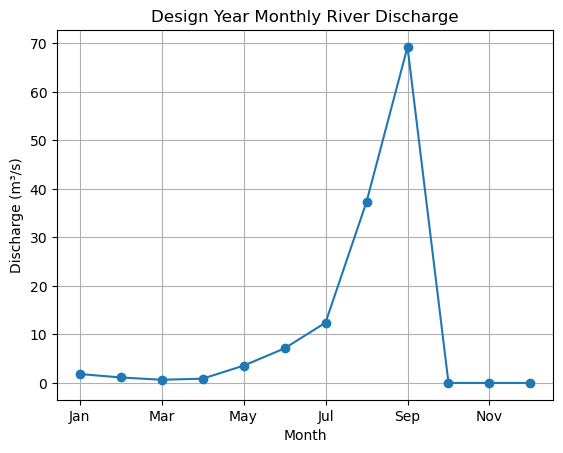

Monthly design year river flow (mm/month):
Jan     1.835418
Feb     1.129750
Mar     0.655914
Apr     0.872222
May     3.555743
Jun     7.114024
Jul    12.429724
Aug    37.325594
Sep    69.278912
Oct     0.000000
Nov     0.000000
Dec     0.000000
Name: Discharge, dtype: float64


In [114]:
df_river2.index = pd.to_datetime(df_river2.index)
river_series = pd.to_numeric(df_river2["Discharge"], errors="coerce")
river_monthly = river_series.resample("M").mean()

river_design_year = (
    river_monthly
    .groupby(river_monthly.index.month)
    .mean()
    .reindex(range(1,13))      # ensures all months exist
    .fillna(0)                 # replace missing with 0
)

river_design_year.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print(river_design_year)

plt.figure()
river_design_year.plot(marker="o")
plt.title("Design Year Monthly River Discharge")
plt.ylabel("Discharge (m³/s)")
plt.xlabel("Month")
plt.grid(True)
plt.show()


print("Monthly design year river flow (mm/month):")
print(river_design_year)

In [115]:
area = np.linspace(10000, 40*10000, num = 10)
Cr = 0.31 #runoff coefficient
Percip = precip_design_year #mm/day changes per month
k = 0.08 #seepage coefficient m/day
E = monthly_evap #mm/day evaporation changes per month
Rriver = river_design_year #m3/s
Dirr = 5 #depth of irrigation necessary (mm/day)
Airr = 20*1000 #area of irrigation (m2)
Acatch = 40*1000 #catchment area (m2)

In [116]:

SEC_PER_DAY = 86400.0

def mmday_to_mday(x_mm_day):
    return x_mm_day / 1000.0

def m3s_to_m3day(q_m3s):
    return q_m3s * SEC_PER_DAY

def runoff_catchment_m3day(Cr, P_m_day, Acatch_m2):
    return Cr * P_m_day * Acatch_m2

def pdir_m3day(P_m_day, Ares_m2):
    return P_m_day * Ares_m2

def evap_m3day(E_m_day, Ares_m2):
    return E_m_day * Ares_m2

def seep_m3day(k_m_day, Ares_m2):
    return k_m_day * Ares_m2

def irrigation_m3day(Dirr_m_day, Airr_m2):
    return Dirr_m_day * Airr_m2

def delta_s_m3day(Qriver_in_m3day, P_m_day, E_m_day, Ares_m2, Cr, Acatch_m2, k_m_day, Dirr_m_day, Airr_m2):
    inflow  = runoff_catchment_m3day(Cr, P_m_day, Acatch_m2) + Qriver_in_m3day + pdir_m3day(P_m_day, Ares_m2)
    outflow = evap_m3day(E_m_day, Ares_m2) + seep_m3day(k_m_day, Ares_m2) + irrigation_m3day(Dirr_m_day, Airr_m2)
    return inflow - outflow  # m3/day

def make_design_year_daily(monthly_series, year=2001):
    """
    monthly_series: pandas Series or 1-col DataFrame with 12 values.
                   Index can be 1..12 or Jan..Dec.
    Returns: daily Series (one year) with month-wise constant values.
    """
    if isinstance(monthly_series, pd.DataFrame):
        # take first column
        monthly_series = monthly_series.iloc[:, 0]

    s = monthly_series.copy()

    # Map month names to numbers if needed
    if s.index.dtype == object:
        name_to_num = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,"Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
        s.index = [name_to_num[i] for i in s.index]
        s = s.sort_index()

    idx = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
    out = pd.Series(index=idx, dtype=float)
    for m in range(1, 13):
        out[out.index.month == m] = float(s.loc[m])
    return out




In [117]:
areas_ha = np.linspace(1, 40, 10)

rows = []
for A_ha in areas_ha:
    Ares_m2 = A_ha * 10_000.0

    S = 0.0      # starting storage (m3)
    Smax = 0.0   # required capacity (max storage reached)
    failed = False

    for t in P_m_day.index:
        dS = delta_s_m3day(
            Qriver_in_m3day=float(Qin_m3day.loc[t]),
            P_m_day=float(P_m_day.loc[t]),
            E_m_day=float(E_m_day.loc[t]),
            Ares_m2=Ares_m2,
            Cr=Cr,
            Acatch_m2= Acatch,
            k_m_day = k,
            Dirr_m_day=Dirr,
            Airr_m2=Airr
        )

        S_new = S + dS

        if S_new < 0:
            failed = True
            break

        S = S_new
        if S > Smax:
            Smax = S

    rows.append({"area_ha": A_ha, "feasible": not failed, "required_capacity_m3": Smax})

df_sizing = pd.DataFrame(rows)
print(df_sizing)

feasible = df_sizing[df_sizing["feasible"]].sort_values("area_ha")
if feasible.empty:
    print("\nNo feasible reservoir area found between 1 and 40 ha for these inputs.")
else:
    best = feasible.iloc[0]
    print("\nSmallest feasible reservoir surface area (ha) and required capacity (m3):")
    print(best)


     area_ha  feasible  required_capacity_m3
0   1.000000     False                   0.0
1   5.333333     False                   0.0
2   9.666667     False                   0.0
3  14.000000     False                   0.0
4  18.333333     False                   0.0
5  22.666667     False                   0.0
6  27.000000     False                   0.0
7  31.333333     False                   0.0
8  35.666667     False                   0.0
9  40.000000     False                   0.0

No feasible reservoir area found between 1 and 40 ha for these inputs.
